# UCCSD–VQE for the Pairing Hamiltonian

**Replacing the Coulomb interaction by the constant pairing interaction**

This notebook ports the unitary-coupled-cluster / variational-quantum-eigensolver
(UCCSD–VQE) machinery developed for electrons in a two-dimensional harmonic-oscillator
trap (the *Coulomb* notebook `qdresrefinement_vqe_K12.ipynb`) to the **constant
pairing model** introduced in `week47.ipynb`.

The physical system is four fermions distributed over **four doubly-degenerate
single-particle levels**, interacting through the constant pairing force.  We work
exclusively in the subspace with **no broken pairs** (seniority $\nu=0$, total spin
$S=0$), exactly as in `week47.ipynb`.

For every basis size we compute the ground-state energy with three independent methods
and compare them:

1. **Exact diagonalisation** in the seniority-zero basis — the reference of `week47.ipynb`.
2. **Standard coupled-cluster doubles (CCD)** — the classical solver of `week47.ipynb`.
3. **UCCSD–VQE** — the new quantum-algorithm calculation built here, *along the same
   lines* as the Coulomb-interaction notebook (Jordan–Wigner mapping, particle-number
   penalty, variational ansatz, gradient-based optimisation, state-vector simulation).

### Definition of the basis sizes $k$

Following the prescription requested for this study, $k$ counts the number of
doubly-degenerate single-particle levels that are kept:

| $k$ | levels kept | pair-basis dimension $\binom{k}{2}$ | character |
|----:|:------------|:-----------------------------------:|:----------|
| 2 | $0,1$ | 1 | both pairs in the two lowest levels — the **Hartree–Fock** state, a single Slater determinant |
| 3 | $0,1,2$ | 3 | one extra level available |
| 4 | $0,1,2,3$ | 6 | the full `week47.ipynb` model |

In all cases there are $N=4$ fermions $=2$ pairs.

---
## 1  The pairing Hamiltonian

We use the constant-pairing Hamiltonian of *Lecture Notes in Physics* **936**,
Chapter 8 — the same convention used in `week47.ipynb`:

$$
\hat H \;=\; \delta\sum_{p=0}^{k-1}\, p \sum_{\sigma=\uparrow,\downarrow}
              \hat a^{\dagger}_{p\sigma}\hat a_{p\sigma}
       \;-\;\frac{g}{2}\sum_{p,q=0}^{k-1}
              \hat a^{\dagger}_{p\uparrow}\hat a^{\dagger}_{p\downarrow}
              \hat a_{q\downarrow}\hat a_{q\uparrow}.
$$

Level $p$ (we index from $0$) has single-particle energy $\delta\,p$ and holds one
spin-up and one spin-down fermion.  The interaction destroys a singlet pair on level
$q$ and creates one on level $p$ with constant strength $-g/2$.  We set the spacing
$\delta=1$ throughout and vary $g\in[0,1]$.

### Pair operators and seniority

With the **pair-creation operator** $\hat A^{\dagger}_p=\hat a^{\dagger}_{p\uparrow}
\hat a^{\dagger}_{p\downarrow}$ the interaction reads
$\hat V=-\tfrac{g}{2}\sum_{p,q}\hat A^{\dagger}_p\hat A_q$.
Both terms of $\hat H$ conserve the **seniority** $\nu$ (the number of unpaired
fermions).  Restricting to $\nu=0$ means *every* fermion sits in a pair, which
automatically gives $S=0$.  A seniority-zero state is fully specified by the set of
doubly-occupied levels,
$$
\big|\{p_1,p_2\}\big\rangle=\hat A^{\dagger}_{p_1}\hat A^{\dagger}_{p_2}\,|0\rangle .
$$

### Matrix elements in the pair basis

For $|D\rangle=|\{p_1,p_2\}\rangle$ (two pairs):

$$
\langle D|\hat H|D\rangle = 2\delta\!\!\sum_{p\in D}\! p \;-\; g,
\qquad
\langle D'|\hat H|D\rangle =
\begin{cases}-\dfrac{g}{2}, & D' \text{ differs from } D \text{ by one pair move},\\[4pt]
0, & \text{otherwise.}\end{cases}
$$

The diagonal interaction $-g$ is the $\tfrac{g}{2}\!\times\!2$ contribution of the two
occupied pairs from the $p=q$ terms.  States differing by **two** pair moves are not
directly coupled.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import minimize
import time

# ---------------------------------------------------------------------------
# Global parameters of the model
# ---------------------------------------------------------------------------
DELTA   = 1.0    # single-particle level spacing  (xi = 1)
N_PAIRS = 2      # N/2  (N = 4 fermions)
K_LIST  = (2, 3, 4)

def E_HF(g, delta=DELTA):
    '''Hartree-Fock (reference) energy = <{0,1}|H|{0,1}> = 2*delta*(0+1) - g.'''
    return 2.0*delta - g

print('Parameters: delta =', DELTA, ', N =', 2*N_PAIRS, 'fermions (', N_PAIRS, 'pairs )')
print('Basis sizes k =', K_LIST, ' -> pair-basis dims', [len(list(combinations(range(k),N_PAIRS))) for k in K_LIST])

Parameters: delta = 1.0 , N = 4 fermions ( 2 pairs )
Basis sizes k = (2, 3, 4)  -> pair-basis dims [1, 3, 6]


---
## 2  Exact diagonalisation (no broken pairs)

We build the Hamiltonian directly in the seniority-zero pair basis
$\{|\{p_1,p_2\}\rangle\}$ and diagonalise it.  For $k=4$ this is the $6\times6$ matrix
of `week47.ipynb`; for $k=3$ it is $3\times3$ and for $k=2$ it is the single number
$E=2\delta-g$ (the Hartree–Fock state).

In [2]:
def pairing_seniority0_H(k, g, delta=DELTA, n_pairs=N_PAIRS):
    '''Pairing Hamiltonian in the seniority-zero (no-broken-pair) basis.

    Basis states are tuples of doubly-occupied levels, dim = C(k, n_pairs).
        H_DD   = 2*delta*sum(levels in D) - (g/2)*n_pairs        (= -g for 2 pairs)
        H_D'D  = -g/2  if D' and D differ by exactly one pair move; 0 otherwise.
    '''
    basis = list(combinations(range(k), n_pairs))
    dim   = len(basis)
    idx   = {s: i for i, s in enumerate(basis)}
    H = np.zeros((dim, dim))
    for i, occ in enumerate(basis):
        H[i, i] = 2.0*delta*sum(occ) - 0.5*g*n_pairs
        occ_set = set(occ)
        for p_out in occ:                       # a pair leaves p_out ...
            for p_in in range(k):               # ... and arrives at p_in
                if p_in in occ_set:
                    continue
                new = tuple(sorted(occ_set - {p_out} | {p_in}))
                H[i, idx[new]] += -0.5*g
    return H, basis


# --- Show the matrices and spectra at the reference strength g = 1 ----------
print('Exact diagonalisation in the seniority-zero (S=0) sector,  delta=1, g=1')
print('=' * 70)
exact_g1 = {}
for k in K_LIST:
    H, basis = pairing_seniority0_H(k, g=1.0)
    evals = np.linalg.eigvalsh(H)
    exact_g1[k] = evals
    print(f'\nk = {k}   dim = {len(basis)}   basis (occupied levels): {basis}')
    print('  H =')
    for row in H:
        print('     ', '  '.join(f'{v:+5.2f}' for v in row))
    print(f'  eigenvalues: ' + '  '.join(f'{e:+.5f}' for e in evals))
    print(f'  E0 = {evals[0]:+.6f}   E_HF = {E_HF(1.0):+.4f}   '
          f'E_corr = {evals[0]-E_HF(1.0):+.6f}')

Exact diagonalisation in the seniority-zero (S=0) sector,  delta=1, g=1

k = 2   dim = 1   basis (occupied levels): [(0, 1)]
  H =
      +1.00
  eigenvalues: +1.00000
  E0 = +1.000000   E_HF = +1.0000   E_corr = +0.000000

k = 3   dim = 3   basis (occupied levels): [(0, 1), (0, 2), (1, 2)]
  H =
      +1.00  -0.50  -0.50
      -0.50  +3.00  -0.50
      -0.50  -0.50  +5.00
  eigenvalues: +0.79470  +3.05266  +5.15264
  E0 = +0.794697   E_HF = +1.0000   E_corr = -0.205303

k = 4   dim = 6   basis (occupied levels): [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
  H =
      +1.00  -0.50  -0.50  -0.50  -0.50  +0.00
      -0.50  +3.00  -0.50  -0.50  +0.00  -0.50
      -0.50  -0.50  +5.00  +0.00  -0.50  -0.50
      -0.50  -0.50  +0.00  +5.00  -0.50  -0.50
      -0.50  +0.00  -0.50  -0.50  +7.00  -0.50
      +0.00  -0.50  -0.50  -0.50  -0.50  +9.00
  eigenvalues: +0.63555  +2.93538  +5.00000  +5.00000  +7.20894  +9.22013
  E0 = +0.635548   E_HF = +1.0000   E_corr = -0.364452


The $k=4$ matrix reproduces exactly the $6\times6$ array of `week47.ipynb`
(diagonal $2-g,\,4-g,\,6-g,\,6-g,\,8-g,\,10-g$, off-diagonal $-g/2$, with zeros where
two pair moves are needed).  Enlarging the basis lowers the ground state below the
Hartree–Fock value $E_{\rm HF}=2-g$; the difference is the correlation energy.

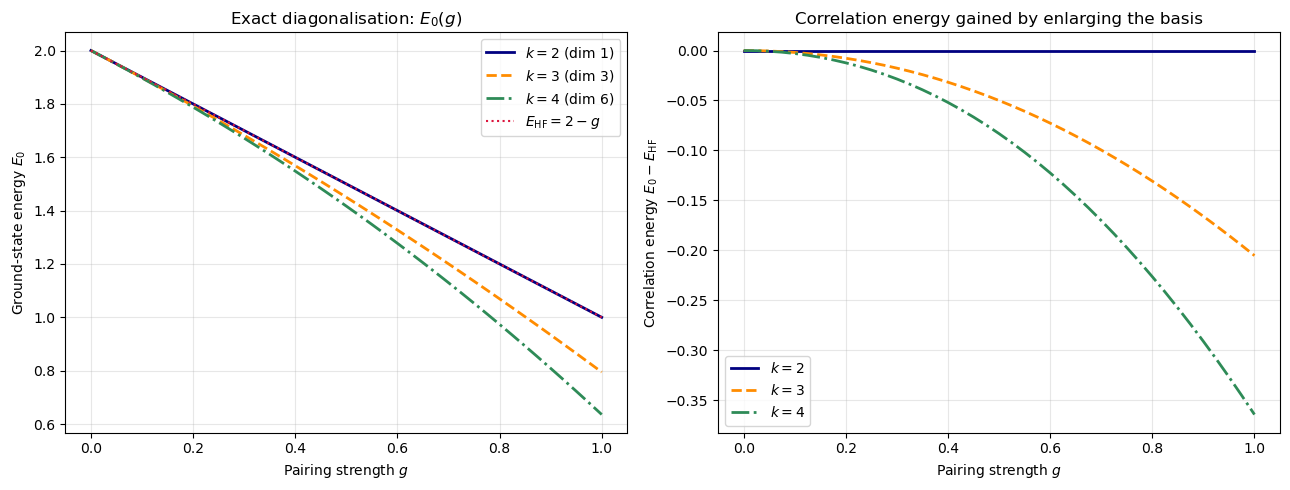

At g=1:  E_corr(k=2)=0,  E_corr(k=3)=-0.20530,  E_corr(k=4)=-0.36445


In [3]:
# --- Correlation energy vs g (exact), analogue of the week47 plot -----------
g_vals = np.linspace(0.0, 1.0, 41)
E0_exact = {k: np.array([np.linalg.eigvalsh(pairing_seniority0_H(k, g)[0])[0]
                         for g in g_vals]) for k in K_LIST}

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
styles = {2: ('navy', '-'), 3: ('darkorange', '--'), 4: ('seagreen', '-.')}

for k, (c, ls) in styles.items():
    axA.plot(g_vals, E0_exact[k], color=c, ls=ls, lw=2, label=f'$k={k}$ (dim {len(list(combinations(range(k),2)))})')
axA.plot(g_vals, E_HF(g_vals), color='crimson', ls=':', lw=1.5, label=r'$E_{\rm HF}=2-g$')
axA.set_xlabel('Pairing strength $g$'); axA.set_ylabel(r'Ground-state energy $E_0$')
axA.set_title('Exact diagonalisation: $E_0(g)$'); axA.legend(); axA.grid(alpha=0.3)

for k, (c, ls) in styles.items():
    axB.plot(g_vals, E0_exact[k]-E_HF(g_vals), color=c, ls=ls, lw=2, label=f'$k={k}$')
axB.set_xlabel('Pairing strength $g$'); axB.set_ylabel(r'Correlation energy $E_0-E_{\rm HF}$')
axB.set_title('Correlation energy gained by enlarging the basis'); axB.legend(); axB.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('At g=1:  E_corr(k=2)=0,  E_corr(k=3)=%.5f,  E_corr(k=4)=%.5f'
      % (E0_exact[3][-1]-E_HF(1.0), E0_exact[4][-1]-E_HF(1.0)))

---
## 3  Standard coupled-cluster (CCD)

`week47.ipynb` solves the pairing problem with the classical **coupled-cluster doubles
(CCD)** equations of *LNP 936*, Chapter 8.  Because singles vanish identically for the
pairing force in a Hartree–Fock basis (see Section 5), CCD already contains the full
singles-and-doubles content for this problem.  We keep that solver unchanged and simply
generalise the particle/hole counts so it runs for $k=2,3,4$:

* holes (occupied spin-orbitals) $=$ levels $0,1$ $\Rightarrow$ `hnum = 4`,
* particles (virtual spin-orbitals) $=$ levels $2,\dots,k-1$ $\Rightarrow$ `pnum = 2(k-2)`.

For $k=2$ there are no particle states, so CCD returns the Hartree–Fock energy.

In [4]:
# ===== Coupled-cluster doubles for the pairing model (from week47.ipynb) =====
def init_pairing_v(g, pnum, hnum):
    """Pairing interaction tensor in the pppp, pphh and hhhh channels."""
    v_pppp = np.zeros((pnum, pnum, pnum, pnum))
    v_pphh = np.zeros((pnum, pnum, hnum, hnum))
    v_hhhh = np.zeros((hnum, hnum, hnum, hnum))
    gval = -0.5*g
    for a in range(0, pnum, 2):
        for b in range(0, pnum, 2):
            v_pppp[a,a+1,b,b+1]= gval; v_pppp[a+1,a,b,b+1]=-gval
            v_pppp[a,a+1,b+1,b]=-gval; v_pppp[a+1,a,b+1,b]= gval
    for a in range(0, pnum, 2):
        for i in range(0, hnum, 2):
            v_pphh[a,a+1,i,i+1]= gval; v_pphh[a+1,a,i,i+1]=-gval
            v_pphh[a,a+1,i+1,i]=-gval; v_pphh[a+1,a,i+1,i]= gval
    for j in range(0, hnum, 2):
        for i in range(0, hnum, 2):
            v_hhhh[j,j+1,i,i+1]= gval; v_hhhh[j+1,j,i,i+1]=-gval
            v_hhhh[j,j+1,i+1,i]=-gval; v_hhhh[j+1,j,i+1,i]= gval
    return v_pppp, v_pphh, v_hhhh

def init_pairing_fock(delta, g, pnum, hnum):
    """Diagonal Fock matrix in the Hartree-Fock basis."""
    dv, gval = 0.5*delta, -0.5*g
    f_pp = np.zeros((pnum, pnum)); f_hh = np.zeros((hnum, hnum))
    for i in range(0, hnum, 2):
        f_hh[i,i] = dv*i + gval; f_hh[i+1,i+1] = dv*i + gval
    for a in range(0, pnum, 2):
        f_pp[a,a] = dv*(hnum+a); f_pp[a+1,a+1] = dv*(hnum+a)
    return f_pp, f_hh

def init_t2(v_pphh, f_pp, f_hh):
    """MBPT2 starting amplitudes."""
    pnum, hnum = len(f_pp), len(f_hh)
    t2 = np.zeros((pnum, pnum, hnum, hnum))
    for i in range(hnum):
        for j in range(hnum):
            for a in range(pnum):
                for b in range(pnum):
                    t2[a,b,i,j] = v_pphh[a,b,i,j]/(f_hh[i,i]+f_hh[j,j]-f_pp[a,a]-f_pp[b,b])
    return t2

def ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2):
    """One CCD iteration (Eq. 8.34 with the intermediates 8.46-8.49)."""
    pnum, hnum = len(f_pp), len(f_hh)
    Hbar = ( v_pphh
           + np.einsum('bc,acij->abij', f_pp, t2) - np.einsum('ac,bcij->abij', f_pp, t2)
           - np.einsum('abik,kj->abij', t2, f_hh) + np.einsum('abjk,ki->abij', t2, f_hh)
           + 0.5*np.einsum('abcd,cdij->abij', v_pppp, t2)
           + 0.5*np.einsum('abkl,klij->abij', t2, v_hhhh) )
    chi_hh = 0.5*np.einsum('cdkl,cdjl->kj', v_pphh, t2)
    Hbar  -= (np.einsum('abik,kj->abij', t2, chi_hh) - np.einsum('abik,kj->abji', t2, chi_hh))
    chi_pp = -0.5*np.einsum('cdkl,bdkl->cb', v_pphh, t2)
    Hbar  += (np.einsum('acij,cb->abij', t2, chi_pp) - np.einsum('acij,cb->baij', t2, chi_pp))
    chi_hhhh = 0.5*np.einsum('cdkl,cdij->klij', v_pphh, t2)
    Hbar  += 0.5*np.einsum('abkl,klij->abij', t2, chi_hhhh)
    chi_phph = 0.5*np.einsum('cdkl,dblj->bkcj', v_pphh, t2)
    Hbar  += ( np.einsum('bkcj,acik->abij', chi_phph, t2) - np.einsum('bkcj,acik->baij', chi_phph, t2)
             - np.einsum('bkcj,acik->abji', chi_phph, t2) + np.einsum('bkcj,acik->baji', chi_phph, t2) )
    t2n = np.zeros_like(t2)
    for i in range(hnum):
        for j in range(hnum):
            for a in range(pnum):
                for b in range(pnum):
                    t2n[a,b,i,j] = t2[a,b,i,j] + Hbar[a,b,i,j]/(f_hh[i,i]+f_hh[j,j]-f_pp[a,a]-f_pp[b,b])
    return t2n

def ccd_energy(v_pphh, t2):
    return 0.25*np.einsum('abij,abij', v_pphh, t2)

def run_ccd(k, g, delta=DELTA, niter=300, mix=0.5, tol=1e-13):
    """Return (E_total, E_corr) for the pairing CCD at basis size k."""
    hnum, pnum = 4, 2*(k-2)
    Eref = E_HF(g, delta)
    if pnum == 0:                       # k = 2: no virtual states
        return Eref, 0.0
    v_pppp, v_pphh, v_hhhh = init_pairing_v(g, pnum, hnum)
    f_pp, f_hh = init_pairing_fock(delta, g, pnum, hnum)
    t2  = init_t2(v_pphh, f_pp, f_hh)
    erg = ccd_energy(v_pphh, t2)
    for _ in range(niter):
        t2n  = ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2)
        ergn = ccd_energy(v_pphh, t2n)
        t2   = mix*t2n + (1.0-mix)*t2
        if abs(ergn - erg) < tol:
            erg = ergn; break
        erg = ergn
    return Eref + erg, erg


print('Coupled-cluster doubles (CCD) at g = 1, compared with exact diagonalisation')
print('=' * 70)
for k in K_LIST:
    Etot, Ecorr = run_ccd(k, 1.0)
    E0 = exact_g1[k][0]
    print(f'  k = {k}:  E_CCD = {Etot:+.6f}  (corr {Ecorr:+.6f})   '
          f'E_exact = {E0:+.6f}   diff = {Etot-E0:+.2e}')

Coupled-cluster doubles (CCD) at g = 1, compared with exact diagonalisation
  k = 2:  E_CCD = +1.000000  (corr +0.000000)   E_exact = +1.000000   diff = +0.00e+00
  k = 3:  E_CCD = +0.794697  (corr -0.205303)   E_exact = +0.794697   diff = +1.42e-13
  k = 4:  E_CCD = +0.630443  (corr -0.369557)   E_exact = +0.635548   diff = -5.11e-03


---
## 4  Qubit encoding: Jordan–Wigner mapping

We now follow the *Coulomb* notebook's recipe exactly, only swapping the interaction.
Each spin-orbital becomes one qubit.  With $k$ levels there are $2k$ spin-orbitals and
therefore $2k$ qubits ($k=2\!:4$ qubits, $k=3\!:6$, $k=4\!:8$).  We order the qubits as

$$\text{qubit index} = 2p + \sigma,\qquad \sigma=0\ (\uparrow),\;1\ (\downarrow),$$

so level $p$ occupies qubits $2p$ and $2p+1$.  The fermionic operators use the
Jordan–Wigner transformation
$$
\hat a^{\dagger}_j \;=\; \Big(\textstyle\bigotimes_{l<j} Z_l\Big)\,\frac{X_j-iY_j}{2},
$$
identical to the `jw_create` helper of the Coulomb notebook.  The second-quantised
Hamiltonian becomes a $2^{2k}\times2^{2k}$ matrix that we split as
$$\hat H(g) = \hat H_{\rm kin} + g\,\hat W,$$
with $g$-independent pieces, so the $g$-sweep in Section 6 is cheap.  The Hartree–Fock
reference is $|\,1111\,0\cdots0\,\rangle$ — the two lowest levels doubly occupied.

In [5]:
# ---------------------------------------------------------------------------
# Jordan-Wigner operators (same construction as the Coulomb notebook)
# ---------------------------------------------------------------------------
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]],  dtype=complex)
Y  = np.array([[0,-1j],[1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0,-1]],  dtype=complex)

def kron_n(*ops):
    r = ops[0]
    for o in ops[1:]:
        r = np.kron(r, o)
    return r

def jw_create(j, n):
    """Jordan-Wigner creation operator (c-dagger)_j on n qubits."""
    ops = [Z if l < j else ((X - 1j*Y)/2 if l == j else I2) for l in range(n)]
    return kron_n(*ops)

def jw_annihilate(j, n):
    return jw_create(j, n).conj().T

def number_op(j, n):
    return jw_create(j, n) @ jw_annihilate(j, n)

def pairing_H_parts(k, delta=DELTA):
    """Return (H_kin, W, N_op, nq) with H(g) = H_kin + g*W, real symmetric."""
    nq, dim = 2*k, 2**(2*k)
    H_kin = np.zeros((dim, dim), dtype=complex)
    for so in range(nq):
        H_kin += delta*(so // 2) * number_op(so, nq)          # eps_p = delta*p
    W = np.zeros((dim, dim), dtype=complex)
    for p in range(k):
        for q in range(k):                                    # -g/2 * A_p-dagger A_q
            W += -0.5*(jw_create(2*p, nq) @ jw_create(2*p+1, nq)
                       @ jw_annihilate(2*q+1, nq) @ jw_annihilate(2*q, nq))
    H_kin = np.real(H_kin)
    W     = np.real((W + W.conj().T)/2)
    N_op  = np.real(sum(number_op(j, nq) for j in range(nq)))
    return H_kin, W, N_op, nq

def hf_index(nq, n_occ=4):
    """Computational-basis index of |1...1 0...0> with the lowest n_occ qubits set."""
    idx = 0
    for j in range(n_occ):
        idx |= 1 << (nq - 1 - j)
    return idx


# --- Build the qubit Hamiltonians and check FCI(N=4) == seniority-zero ED ----
H_PARTS = {k: pairing_H_parts(k) for k in K_LIST}

print('Jordan-Wigner pairing Hamiltonian: FCI in the N=4 sector vs exact diag.')
print('=' * 70)
for k in K_LIST:
    H_kin, W, N_op, nq = H_PARTS[k]
    H = H_kin + 1.0*W                                         # g = 1
    occ4 = [sum(1 << (nq-1-j) for j in c) for c in combinations(range(nq), 4)]
    E_fci = np.linalg.eigvalsh(H[np.ix_(occ4, occ4)])[0]
    print(f'  k = {k}  ({nq} qubits, N=4 sector dim {len(occ4):2d}):  '
          f'E_FCI = {E_fci:+.6f}   E_exact = {exact_g1[k][0]:+.6f}   '
          f'diff = {E_fci-exact_g1[k][0]:+.1e}')

Jordan-Wigner pairing Hamiltonian: FCI in the N=4 sector vs exact diag.
  k = 2  (4 qubits, N=4 sector dim  1):  E_FCI = +1.000000   E_exact = +1.000000   diff = +0.0e+00
  k = 3  (6 qubits, N=4 sector dim 15):  E_FCI = +0.794697   E_exact = +0.794697   diff = +1.1e-16
  k = 4  (8 qubits, N=4 sector dim 70):  E_FCI = +0.635548   E_exact = +0.635548   diff = +0.0e+00


The full $N=4$ ground state coincides with the seniority-zero result to machine
precision: because seniority is a good quantum number and the pairing force is
attractive, the lowest $N=4$ state has no broken pairs.  The quantum calculation
therefore targets exactly the same state as `week47.ipynb`.

---
## 5  UCCSD ansatz and the variational quantum eigensolver

The trial state is the **unitary coupled-cluster singles-and-doubles** wavefunction
$$
|\psi(\boldsymbol\theta)\rangle =
\prod_{\mu}\, e^{\theta_\mu(\hat\tau_\mu-\hat\tau_\mu^{\dagger})}\,|\mathrm{HF}\rangle,
$$
built from number-conserving fermionic excitation generators acting on the
Hartree–Fock reference:

* **singles** $\hat\tau^{a}_{i}=\hat a^{\dagger}_a\hat a_i$ (spin conserving),
* **doubles** $\hat\tau^{ab}_{ij}=\hat a^{\dagger}_a\hat a^{\dagger}_b\hat a_j\hat a_i$
  ($N$- and $S_z$-conserving), with $i,j$ occupied and $a,b$ virtual.

Each factor uses the closed form (valid because $\hat\tau^3=-\hat\tau$ for a single
excitation operator),
$$
e^{\theta\hat\tau}|\phi\rangle =
|\phi\rangle + \sin\theta\,\hat\tau|\phi\rangle + (1-\cos\theta)\,\hat\tau^{2}|\phi\rangle,
$$
so the state vector is updated without forming a matrix exponential.

**Particle-number penalty.**  As in the Coulomb notebook we minimise
$\langle\hat H + \lambda(\hat N-4)^2\rangle$.  Every UCCSD generator conserves $\hat N$,
so $\langle\hat N\rangle=4$ exactly throughout and the penalty is automatically
satisfied; we keep it for parity with the Coulomb workflow.

**Gradients.**  The Coulomb notebook used the two-term parameter-shift rule, exact for
single-qubit $R_y$ rotations.  A fermionic excitation generator has spectrum
$\{-1,0,+1\}$, so its energy carries a frequency-2 component and the naïve two-term
shift is *incomplete* — on hardware one would use the generalised (four-term)
parameter-shift rule.  In this state-vector simulation we evaluate the exact gradient of
the product ansatz directly (verified below against finite differences).

In [6]:
# ---------------------------------------------------------------------------
# UCCSD generators tau_mu = G - G-dagger  (real, since H is real)
# ---------------------------------------------------------------------------
def build_uccsd_generators(k):
    nq = 2*k
    occ = [0, 1, 2, 3]                 # levels 0,1  -> 4 occupied spin-orbitals
    vir = list(range(4, nq))           # levels 2..k-1
    taus, labels = [], []
    # singles: spin-conserving (same parity = same spin)
    for i in occ:
        for a in vir:
            if (i % 2) == (a % 2):
                G = jw_create(a, nq) @ jw_annihilate(i, nq)
                taus.append(np.real(G - G.conj().T)); labels.append(('S', i, a))
    # doubles: number- and Sz-conserving
    for i, j in combinations(occ, 2):
        for a, b in combinations(vir, 2):
            if (i % 2)+(j % 2) == (a % 2)+(b % 2):
                G = (jw_create(a, nq) @ jw_create(b, nq)
                     @ jw_annihilate(j, nq) @ jw_annihilate(i, nq))
                taus.append(np.real(G - G.conj().T)); labels.append(('D', i, j, a, b))
    return taus, labels

def apply_factor(tau, theta, psi):
    """exp(theta*tau)|psi> via the closed form (tau^3 = -tau)."""
    tp = tau @ psi
    return psi + np.sin(theta)*tp + (1.0 - np.cos(theta))*(tau @ tp)

def uccsd_state(params, taus, psi_hf):
    psi = psi_hf.copy()
    for th, tau in zip(params, taus):
        psi = apply_factor(tau, th, psi)
    return psi

GENS = {k: build_uccsd_generators(k) for k in K_LIST}
for k in K_LIST:
    taus, labels = GENS[k]
    ns = sum(l[0] == 'S' for l in labels); nd = sum(l[0] == 'D' for l in labels)
    print(f'k = {k}:  {len(labels):2d} UCCSD generators  ({ns} singles, {nd} doubles)')

k = 2:   0 UCCSD generators  (0 singles, 0 doubles)
k = 3:   8 UCCSD generators  (4 singles, 4 doubles)
k = 4:  26 UCCSD generators  (8 singles, 18 doubles)


In [7]:
# ---------------------------------------------------------------------------
# VQE driver for one (k, g): energy, exact analytic gradient, L-BFGS-B
# ---------------------------------------------------------------------------
def run_uccsd_vqe(k, g, lam=5.0, delta=DELTA, return_state=False):
    H_kin, W, N_op, nq = H_PARTS[k]
    dim   = 2**nq
    H     = H_kin + g*W
    Pen   = lam*((N_op - 4*np.eye(dim)) @ (N_op - 4*np.eye(dim)))
    H_eff = H + Pen
    taus, labels = GENS[k]
    P = len(taus)
    psi_hf = np.zeros(dim); psi_hf[hf_index(nq)] = 1.0

    if P == 0:                                   # k = 2: only the HF state
        E = float(psi_hf @ H @ psi_hf)
        return (E, np.zeros(0), labels, psi_hf) if return_state else (E, np.zeros(0), labels)

    def forward(p):
        states = [psi_hf.copy()]; psi = psi_hf.copy()
        for th, tau in zip(p, taus):
            psi = apply_factor(tau, th, psi); states.append(psi.copy())
        return states

    def E_eff(p):
        psi = uccsd_state(p, taus, psi_hf); return float(psi @ H_eff @ psi)
    def E_phys(p):
        psi = uccsd_state(p, taus, psi_hf); return float(psi @ H @ psi)

    def grad(p):                                  # exact gradient of the product ansatz
        states = forward(p); Hpsi = H_eff @ states[P]; g_ = np.zeros(P)
        for i in range(P):
            v = taus[i] @ states[i+1]             # tau_i commutes with exp(theta_i tau_i)
            for j in range(i+1, P):
                v = apply_factor(taus[j], p[j], v)
            g_[i] = 2.0*float(v @ Hpsi)
        return g_

    res = minimize(E_eff, np.zeros(P), jac=grad, method='L-BFGS-B',
                   options={'ftol': 1e-15, 'gtol': 1e-13, 'maxiter': 5000})
    psi_opt = uccsd_state(res.x, taus, psi_hf)
    if return_state:
        return E_phys(res.x), res.x, labels, psi_opt
    return E_phys(res.x), res.x, labels


# --- Verify the analytic gradient against finite differences (k = 4) --------
taus4, labels4 = GENS[4]; nq4 = 8; dim4 = 2**nq4
H_kin4, W4, N4, _ = H_PARTS[4]
H_eff4 = (H_kin4 + 1.0*W4) + 5.0*((N4 - 4*np.eye(dim4)) @ (N4 - 4*np.eye(dim4)))
psi_hf4 = np.zeros(dim4); psi_hf4[hf_index(nq4)] = 1.0
def _E(p):
    psi = uccsd_state(p, taus4, psi_hf4); return float(psi @ H_eff4 @ psi)
rng = np.random.default_rng(1); p_test = rng.uniform(-0.3, 0.3, len(taus4))
st = [psi_hf4.copy()]; _psi = psi_hf4.copy()
for th, ta in zip(p_test, taus4):
    _psi = apply_factor(ta, th, _psi); st.append(_psi.copy())
Hpsi = H_eff4 @ st[-1]; g_ana = np.zeros(len(taus4))
for i in range(len(taus4)):
    v = taus4[i] @ st[i+1]
    for j in range(i+1, len(taus4)):
        v = apply_factor(taus4[j], p_test[j], v)
    g_ana[i] = 2*float(v @ Hpsi)
h = 1e-6; eye = np.eye(len(taus4))
g_fd = np.array([(_E(p_test + h*eye[i]) - _E(p_test - h*eye[i]))/(2*h)
                 for i in range(len(taus4))])
print(f'analytic vs finite-difference gradient (k=4): max |diff| = {np.max(np.abs(g_ana-g_fd)):.2e}')

analytic vs finite-difference gradient (k=4): max |diff| = 1.94e-09


In [8]:
# --- Run UCCSD-VQE at g = 1 for k = 2, 3, 4 ---------------------------------
print('UCCSD-VQE at g = 1   (delta = 1, HF reference |1111 0...0>)')
print('=' * 70)
vqe_g1 = {}
for k in K_LIST:
    t0 = time.time()
    E_vqe, theta, labels = run_uccsd_vqe(k, 1.0)
    vqe_g1[k] = E_vqe
    E0  = exact_g1[k][0]
    Ecc = run_ccd(k, 1.0)[0]
    smax = max([abs(t) for t, l in zip(theta, labels) if l[0] == 'S'], default=0.0)
    dmax = max([abs(t) for t, l in zip(theta, labels) if l[0] == 'D'], default=0.0)
    print(f'  k = {k}:  E_UCCSD = {E_vqe:+.6f}   E_CCD = {Ecc:+.6f}   E_exact = {E0:+.6f}')
    print(f'            UCCSD - exact = {E_vqe-E0:+.2e} (>=0, variational)   '
          f'CCD - exact = {Ecc-E0:+.2e}')
    print(f'            max|theta_singles| = {smax:.1e}   '
          f'max|theta_doubles| = {dmax:.3f}   ({time.time()-t0:.1f}s)')
    print()
print('Every singles amplitude is zero to machine precision: the pairing force does')
print('not couple to seniority-changing single excitations -- precisely why the')
print('classical solver of week47.ipynb is a *doubles* (CCD) theory.')

UCCSD-VQE at g = 1   (delta = 1, HF reference |1111 0...0>)
  k = 2:  E_UCCSD = +1.000000   E_CCD = +1.000000   E_exact = +1.000000
            UCCSD - exact = +0.00e+00 (>=0, variational)   CCD - exact = +0.00e+00
            max|theta_singles| = 0.0e+00   max|theta_doubles| = 0.000   (0.0s)

  k = 3:  E_UCCSD = +0.794697   E_CCD = +0.794697   E_exact = +0.794697
            UCCSD - exact = +1.11e-16 (>=0, variational)   CCD - exact = +1.42e-13
            max|theta_singles| = 0.0e+00   max|theta_doubles| = 0.255   (0.0s)



  k = 4:  E_UCCSD = +0.636987   E_CCD = +0.630443   E_exact = +0.635548
            UCCSD - exact = +1.44e-03 (>=0, variational)   CCD - exact = -5.11e-03
            max|theta_singles| = 0.0e+00   max|theta_doubles| = 0.276   (1.0s)

Every singles amplitude is zero to machine precision: the pairing force does
not couple to seniority-changing single excitations -- precisely why the
classical solver of week47.ipynb is a *doubles* (CCD) theory.


---
## 6  Comparison across the coupling strength $g$

Finally we sweep the pairing strength $g\in[0,1]$ and overlay the three methods for
each basis size:

* exact diagonalisation (solid),
* CCD (dashed),
* UCCSD–VQE (markers).

The left panel shows the total ground-state energy, the right panel the correlation
energy $E-E_{\rm HF}$.  UCCSD is variational and therefore stays **on or above** the
exact curve, whereas CCD is non-variational and can dip slightly **below** it.

Sweep finished in 16.7 s


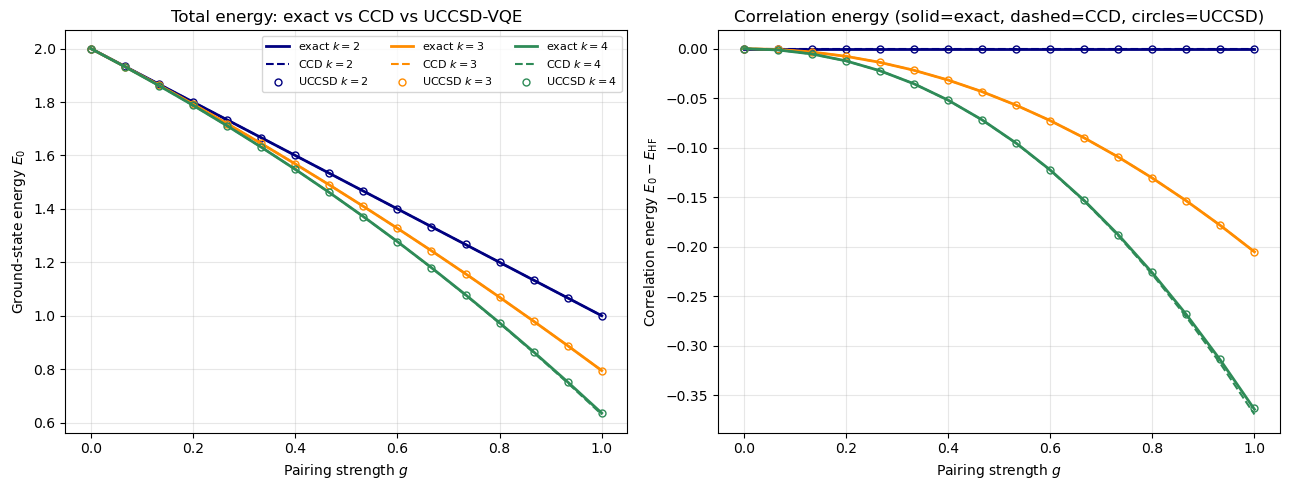

In [8]:
# Sweep g for all three methods (reuses the precomputed H_PARTS and GENS).
g_scan = np.linspace(0.0, 1.0, 16)
E_ex   = {k: [] for k in K_LIST}
E_cc   = {k: [] for k in K_LIST}
E_vq   = {k: [] for k in K_LIST}

t0 = time.time()
for k in K_LIST:
    for g in g_scan:
        E_ex[k].append(np.linalg.eigvalsh(pairing_seniority0_H(k, g)[0])[0])
        E_cc[k].append(run_ccd(k, g)[0])
        E_vq[k].append(run_uccsd_vqe(k, g)[0])
    E_ex[k] = np.array(E_ex[k]); E_cc[k] = np.array(E_cc[k]); E_vq[k] = np.array(E_vq[k])
print(f'Sweep finished in {time.time()-t0:.1f} s')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
colors = {2: 'navy', 3: 'darkorange', 4: 'seagreen'}
for k in K_LIST:
    c = colors[k]
    axL.plot(g_scan, E_ex[k], '-',  color=c, lw=2,                 label=f'exact $k={k}$')
    axL.plot(g_scan, E_cc[k], '--', color=c, lw=1.5,               label=f'CCD $k={k}$')
    axL.plot(g_scan, E_vq[k], 'o',  color=c, ms=5, mfc='none',     label=f'UCCSD $k={k}$')
axL.set_xlabel('Pairing strength $g$'); axL.set_ylabel('Ground-state energy $E_0$')
axL.set_title('Total energy: exact vs CCD vs UCCSD-VQE')
axL.legend(ncol=3, fontsize=8); axL.grid(alpha=0.3)

for k in K_LIST:
    c = colors[k]
    axR.plot(g_scan, E_ex[k]-E_HF(g_scan), '-',  color=c, lw=2)
    axR.plot(g_scan, E_cc[k]-E_HF(g_scan), '--', color=c, lw=1.5)
    axR.plot(g_scan, E_vq[k]-E_HF(g_scan), 'o',  color=c, ms=5, mfc='none')
axR.set_xlabel('Pairing strength $g$'); axR.set_ylabel(r'Correlation energy $E_0-E_{\rm HF}$')
axR.set_title('Correlation energy (solid=exact, dashed=CCD, circles=UCCSD)')
axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
# Numerical comparison table at g = 1
print('Ground-state energy at g = 1  (delta = 1, N = 4)')
print('=' * 64)
print(f'  {"k":>2} | {"exact":>11} | {"CCD":>11} | {"UCCSD-VQE":>11} | '
      f'{"CCD-exact":>10} | {"UCCSD-exact":>11}')
print('  ' + '-'*62)
for k in K_LIST:
    ex, cc, vq = E_ex[k][-1], E_cc[k][-1], E_vq[k][-1]
    print(f'  {k:>2} | {ex:>11.6f} | {cc:>11.6f} | {vq:>11.6f} | '
          f'{cc-ex:>+10.2e} | {vq-ex:>+11.2e}')
print()
print('  CCD reproduces the exact energy for k = 2, 3 and slightly over-binds at k = 4.')
print('  UCCSD-VQE is exact for k = 2, 3 and a tight variational upper bound at k = 4.')

Ground-state energy at g = 1  (delta = 1, N = 4)
   k |       exact |         CCD |   UCCSD-VQE |  CCD-exact | UCCSD-exact
  --------------------------------------------------------------
   2 |    1.000000 |    1.000000 |    1.000000 |  +0.00e+00 |   +0.00e+00
   3 |    0.794697 |    0.794697 |    0.794697 |  +1.42e-13 |   +1.11e-16
   4 |    0.635548 |    0.630443 |    0.636987 |  -5.11e-03 |   +1.44e-03

  CCD reproduces the exact energy for k = 2, 3 and slightly over-binds at k = 4.
  UCCSD-VQE is exact for k = 2, 3 and a tight variational upper bound at k = 4.


---
## 7  Summary

Starting from the Coulomb-interaction UCCSD–VQE notebook, we replaced the two-body
interaction by the constant pairing force of `week47.ipynb` and rebuilt the full
pipeline for $N=4$ fermions in $k=2,3,4$ doubly-degenerate levels, restricted to the
no-broken-pair (seniority-zero) sector.

**What was kept from the Coulomb workflow** — the Jordan–Wigner mapping to $2k$ qubits,
the particle-number penalty $\lambda(\hat N-4)^2$, a state-vector UCCSD ansatz with
singles and doubles, gradient-based optimisation (L-BFGS-B), and benchmarking against
the exact ground state.

**What was kept from `week47.ipynb`** — the exact diagonalisation in the seniority-zero
pair basis (the $6\times6$ matrix for $k=4$) and the classical CCD solver, both
generalised to $k=2,3,4$.

**Findings.**

* For $k=2$ the basis is a single Slater determinant, so all three methods return the
  Hartree–Fock energy $E=2-g$ with zero correlation.
* All **singles amplitudes vanish identically** — the pairing force only connects
  seniority-zero pair configurations, which is exactly why the classical theory of
  `week47.ipynb` is formulated as coupled-cluster *doubles*.
* The full $N=4$ FCI ground state lies entirely in the no-broken-pair sector, so the
  quantum calculation targets the same state as the exact diagonalisation.
* At $g=1$, $k=4$: CCD ($0.6304$) sits just below the exact energy ($0.6355$, it is
  non-variational), while UCCSD–VQE ($0.6370$) is a tight variational upper bound; for
  $k\le3$ both reproduce the exact result.

The notebook thus provides a clean three-way comparison — exact diagonalisation,
classical CCD, and UCCSD–VQE — for the constant pairing model.